# Procedural program to get and analyze RSS-Newsfeeds

## Libraries and settings

In [1]:
# Libraries
import os
import requests
import pandas as pd
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from requests_html import HTMLSession

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Show current working directory
print(os.getcwd())

/workspaces/scientific_programming/Week_08/challenge


## Functions to get the content of RSS-Feeds

In [2]:
def get_source(url):
    """
    Provides source code of the website of the specified URL.

    :param url: URL of the page to scrape. Type = str
    :return: Response from serrver request. Type = requests_html.HTMLResponse
    """
    try:
        session = HTMLSession()
        response = session.get(url)
        return response
    except requests.exceptions.RequestException as e:
        print(e)

def get_single_feed(url):
    """
    Derives the content of a single RSS-Feed for the provided URL.

    :param url: URL of the page to scrape. Type = str
    :return: HTTP response object from requests_html. Type = pandas.DataFrame
    """
    response = get_source(url)
    rows = []

    with response as r:
        items = r.html.find("item", first=False)
        for item in items:
            title = item.find('title', first=True).text
            pubDate = item.find('pubDate', first=True).text
            guid = item.find('guid', first=True).text
            description_element = item.find('description', first=True)
            
            # Check if 'description' element exists before accessing 'text'
            description = description_element.text if description_element is not None else ""
            
            row = {'title': title, 'pubDate': pubDate, 'guid': guid, 'description': description}
            rows.append(row)

    df = pd.DataFrame(rows)
    return df

def get_multiple_feeds(url_list):
    """
    Derives the content on RSS-Feed for the provided list of URLs.

    :param url: URL of the page to scrape. Type = str
    :return: HTTP response object from requests_html. Type = pandas.DataFrame
    """
    
    df = pd.DataFrame(columns = ['title', 'pubDate', 'guid', 'description'])

    for url in url_list:

        df_iter = get_single_feed(url)
        df = pd.concat([df, df_iter], ignore_index=True)

    return df


## Getting infos from single RSS-Feed

In [3]:
# Call functions for single feed
df_feed = get_single_feed('https://www.nzz.ch/international.rss')
df_feed.head(10)

,title,pubDate,guid,description
0,Streit an der Brandmauer: Die künftige deutsch...,"Wed, 16 Apr 2025 09:58:01 GMT",ld.1880419,"Spitzenpolitiker der Union plädieren dafür, de..."
1,In Finnland sind die Rechtsnationalen gescheit...,"Wed, 16 Apr 2025 03:30:00 GMT",ld.1880148,Über den Aufstieg und den Abstieg der Finnenpa...
2,WHO beschliesst historischen Pandemievertrag –...,"Wed, 16 Apr 2025 09:30:03 GMT",ld.1880531,Die Mitgliedstaaten der Weltgesundheitsorganis...
3,Israels Offensive im Gazastreifen weitet sich ...,"Tue, 15 Apr 2025 15:00:00 GMT",ld.1880320,In immer mehr Gebieten fordert Israel die Mens...
4,Joe Biden: «Diese neue Regierung hat so viel S...,"Wed, 16 Apr 2025 08:59:59 GMT",ld.1880488,Erstmals seit Beginn von Donald Trumps zweiter...
5,NZZ GEOPOLITIK - USA gegen China: Wer lässt im...,"Wed, 16 Apr 2025 03:30:00 GMT",ld.1880383,US-Präsident Trump hat China als einziges Land...
6,NZZ AKZENT - Ikone der türkischen Opposition –...,"Wed, 16 Apr 2025 03:30:00 GMT",ld.1880371,Seit der Verhaftung von Ekrem Imamoglu spricht...
7,INTERVIEW - «Die Asiaten lassen sich von der A...,"Wed, 16 Apr 2025 03:30:00 GMT",ld.1879569,"Der Politologe Kishore Mahbubani sagt, der Wes..."
8,"«Santa Maria!», rufen sie, und dann fliesst di...","Wed, 16 Apr 2025 03:30:00 GMT",ld.1876551,Seit dem Mittelalter werden im südlichen Apenn...
9,Dugin ist überall: Der rechtsextreme Philosoph...,"Tue, 15 Apr 2025 09:40:39 GMT",ld.1879585,Der Ultranationalist Alexander Dugin profitier...


## Getting infos from multiple RSS-Feeds

In [4]:
# List with RSS-Feeds (germ. and engl.)

url_list = ['https://www.spiegel.de/schlagzeilen/index.rss',
            'https://www.nzz.ch/international.rss',
            'https://rss.nytimes.com/services/xml/rss/nyt/Europe.xml',
            'https://rss.nytimes.com/services/xml/rss/nyt/World.xml']

# Function call
df_multi_feeds = get_multiple_feeds(url_list)
df_multi_feeds.head(100)

,title,pubDate,guid,description
0,Gazakrieg: Israel Katz will Hilfslieferungen w...,"Wed, 16 Apr 2025 11:58:00 +0200",https://www.spiegel.de/ausland/gazakrieg-israe...,Israel und die Hamas sind erneut weit von eine...
1,Schach: Ju Wenjun dominiert – so eine WM gab e...,"Wed, 16 Apr 2025 11:54:00 +0200",https://www.spiegel.de/sport/schach-ju-wenjun-...,Die Chinesin Ju Wenjun dominierte die Schach-W...
2,Schwimmunterricht: Strenggläubige Kinder müsse...,"Wed, 16 Apr 2025 11:49:00 +0200",https://www.spiegel.de/panorama/bildung/schwim...,Angehörige einer kleinen christlichen Gruppe w...
3,Cong you bing: Rezept für feinblättrige Street...,"Wed, 16 Apr 2025 11:33:00 +0200",https://www.spiegel.de/start/cong-you-bing-rez...,China verwandelt den Handelskrieg auf TikTok i...
4,Schweiz: Bergsteiger brechen Rekord an drei No...,"Wed, 16 Apr 2025 11:27:00 +0200",https://www.spiegel.de/sport/schweiz-bergsteig...,"Kurz nach Mitternacht ging es los, später gab ..."
...,...,...,...,...
95,"Attackers Target Prisons in France, Burning Ve...","Tue, 15 Apr 2025 13:45:29 +0000",https://www.nytimes.com/2025/04/15/world/europ...,The office of France’s counterterrorism prosec...
96,Van Gogh’s Last Painting Poses a Problem for a...,"Tue, 15 Apr 2025 19:19:15 +0000",https://www.nytimes.com/2025/04/15/world/europ...,It was recently determined that the artist pai...
97,Tuesday Briefing: El Salvador Will Not Return ...,"Tue, 15 Apr 2025 05:00:13 +0000",https://www.nytimes.com/2025/04/15/briefing/el...,"Plus, remembering Mario Vargas Llosa."
98,A Crisis at a British Steel Mill Has Cast a Sh...,"Tue, 15 Apr 2025 04:01:05 +0000",https://www.nytimes.com/2025/04/15/world/europ...,"Britain was edging closer to China, but a disp..."


## Finding the k most frequent words per RSS-Feed title

In [5]:
for item in df_multi_feeds['title']:

    from collections import Counter
    
    split_txt = item.split()
    Counter = Counter(split_txt)
    most_occur = Counter.most_common(5)
    print(most_occur)

[('Gazakrieg:', 1), ('Israel', 1), ('Katz', 1), ('will', 1), ('Hilfslieferungen', 1)]
[('Schach:', 1), ('Ju', 1), ('Wenjun', 1), ('dominiert', 1), ('–', 1)]
[('Schwimmunterricht:', 1), ('Strenggläubige', 1), ('Kinder', 1), ('müssen', 1), ('laut', 1)]
[('für', 2), ('Cong', 1), ('you', 1), ('bing:', 1), ('Rezept', 1)]
[('Schweiz:', 1), ('Bergsteiger', 1), ('brechen', 1), ('Rekord', 1), ('an', 1)]
[('Cate', 1), ('Blanchett:', 1), ('Karriereende?', 1), ('»Ich', 1), ('meine', 1)]
[('Potsdam:', 1), ('Wachmann', 1), ('in', 1), ('Flüchtlingsunterkunft', 1), ('getötet', 1)]
[('Donald', 1), ('Trump:', 1), ('Weißes', 1), ('Haus', 1), ('schränkt', 1)]
[('Streetstyle:', 1), ('Die', 1), ('dezente', 1), ('Coolness', 1), ('der', 1)]
[('und', 2), ('Kinderwunsch', 1), ('Endometriose:', 1), ('Ein', 1), ('Cocktail', 1)]
[('CDU/CSU', 1), ('und', 1), ('SPD:', 1), ('Warum', 1), ('wir', 1)]
[('Meta:', 1), ('Tech-Riese', 1), ('wollte', 1), ('Prozess', 1), ('um', 1)]
[('Berlin:', 1), ('Palliativarzt', 1), ('sol

## Create a wordcloud with the most frequent words in RSS-Feed titles

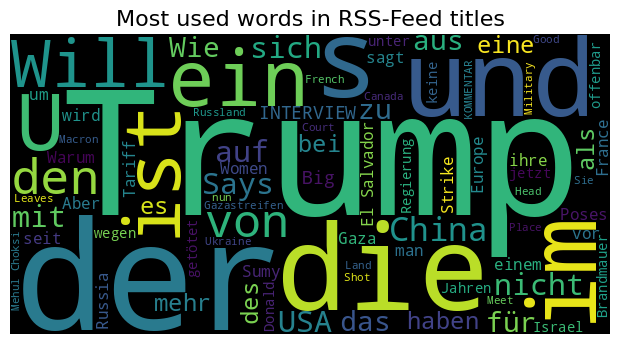

In [6]:
# Wordcloud function
def wordCloud_generator(data, title=None):
    """
    Creates a plot of a word cloud based on the given data

    :param data: input data. Type = str
    :param title: plot title. Type

    """
    wordcloud = WordCloud(height=300,
                          width=600,
                          background_color ='black',
                          min_font_size = 10
                         ).generate(" ".join(data.values))
    
    # Plot the WordCloud image                        
    plt.figure(figsize = (6, 4), facecolor = None) 
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off") 
    plt.tight_layout(pad = 0) 
    plt.title(title,fontsize=16)
    plt.show()
    
# Create Wordcloud
wordCloud_generator(df_multi_feeds['title'], 
                    title="Most used words in RSS-Feed titles")

### Jupyter notebook --footer info-- (please always provide this at the end of each notebook)

In [7]:
import os
import platform
import socket
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Linux | 6.8.0-1021-azure
Datetime: 2025-04-16 10:06:14
Python Version: 3.11.11
-----------------------------------
